In [2]:

######## snakemake preamble start (automatically inserted, do not edit) ########
library(methods)
Snakemake <- setClass(
    "Snakemake",
    slots = c(
        input = "list",
        output = "list",
        params = "list",
        wildcards = "list",
        threads = "numeric",
        log = "list",
        resources = "list",
        config = "list",
        rule = "character",
        bench_iteration = "numeric",
        scriptdir = "character",
        source = "function"
    )
)
snakemake <- Snakemake(
    input = list('data/raw/fastq/filtered/SRR32393053_1.fastq', 'data/raw/fastq/filtered/SRR32393053_2.fastq', 'data/raw/fastq/filtered/SRR32393054_1.fastq', 'data/raw/fastq/filtered/SRR32393054_2.fastq', 'data/raw/fastq/filtered/SRR32393055_1.fastq', 'data/raw/fastq/filtered/SRR32393055_2.fastq', 'data/raw/fastq/filtered/SRR32393056_1.fastq', 'data/raw/fastq/filtered/SRR32393056_2.fastq', 'data/raw/fastq/filtered/SRR32393057_1.fastq', 'data/raw/fastq/filtered/SRR32393057_2.fastq'),
    output = list('results/ASVs_tax.tsv', 'results/ASVs_counts.tsv', 'results/ASVs.fa', "tax" = 'results/ASVs_tax.tsv', "counts" = 'results/ASVs_counts.tsv', "fasta" = 'results/ASVs.fa'),
    params = list(),
    wildcards = list(),
    threads = 1,
    log = list(),
    resources = list('tmpdir', "tmpdir" = '/tmp'),
    config = list("pathvars" = list("data_initial" = 'data/initial', "data_raw" = 'data/raw', "samples" = 'data/raw/fastq', "samples_filter" = 'data/raw/fastq/filtered', "temp" = 'data/temp', "reports" = 'results/reports', "figures" = 'results/figures')),
    rule = 'Dada2',
    bench_iteration = as.numeric(NA),
    scriptdir = '/mnt/d/Projects/03_Science_and_Education/kyh_microbio_depression/workflow/steps/02_taxa_with_dada2/notebooks',
    source = function(...){
        old_wd <- getwd()
        on.exit(setwd(old_wd), add = TRUE)

        is_url <- grepl("^https?://", snakemake@scriptdir)
        file <- ifelse(is_url, file.path(snakemake@scriptdir, ...), ...)
        if (!is_url) setwd(snakemake@scriptdir)
        source(file)
    }
)
setwd('/mnt/d/Projects/03_Science_and_Education/kyh_microbio_depression');

######## snakemake preamble end #########


# Import libs and load samples

In [3]:
library(dada2); packageVersion('dada2')
library(DECIPHER); packageVersion('DECIPHER')

Loading required package: Rcpp



[1] ‘1.38.0’

Loading required package: Biostrings

Loading required package: BiocGenerics

Loading required package: generics


Attaching package: ‘generics’


The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, saveRDS, table, tapply, unique,
    unsplit, which.max, which.min


Loading required package: S4Vectors

Loading required package: stats4


Attaching package: ‘S4Vectors’


The following object is masked from ‘packag

[1] ‘3.6.0’

In [4]:
extract_oneside_reads <- function(reads_list, reverse=F) {
    filter_regexp = '_1\\.'
    if (reverse) {
        filter_regexp = '_2\\.'
    }
    return(
        reads_list[grepl(filter_regexp, reads_list)] |>
            as.character()
    )
}

for_reads <- extract_oneside_reads(snakemake@input, F)
rev_reads <- extract_oneside_reads(snakemake@input, T)

In [5]:
source("workflow/scripts/reads_len_distr.R", chdir = TRUE)
reads_len_stat(for_reads, rev_reads)

Loading required package: BiocParallel

Loading required package: Rsamtools

Loading required package: GenomicRanges

Loading required package: GenomicAlignments

Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, rowCounts, rowCummaxs, rowCummins, rowCumprods,
    rowCumsums, row

forward reads:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    230     230     230     230     230     230 

reverse reads:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    230     230     230     230     230     230 


# Error model

22773680 total bases in 99016 reads from 5 samples will be used for learning the error rates.


Warning message in scale_y_log10():
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 164 rows containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 164 rows containing missing values or values outside the scale range
(`geom_line()`).”


22773680 total bases in 99016 reads from 5 samples will be used for learning the error rates.


Warning message in scale_y_log10():
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 164 rows containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 164 rows containing missing values or values outside the scale range
(`geom_line()`).”


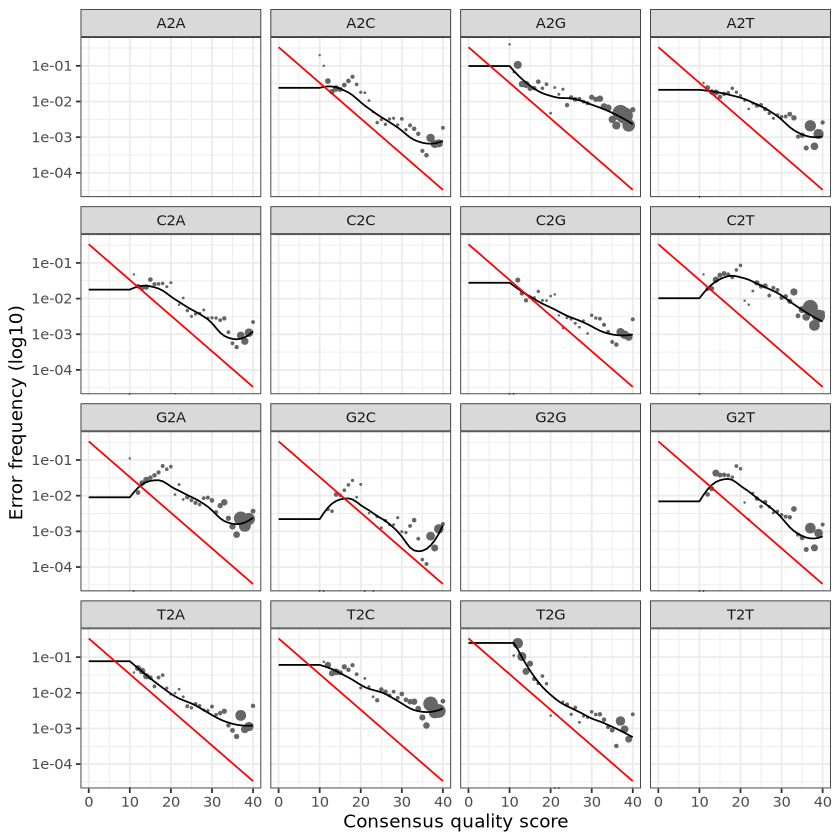

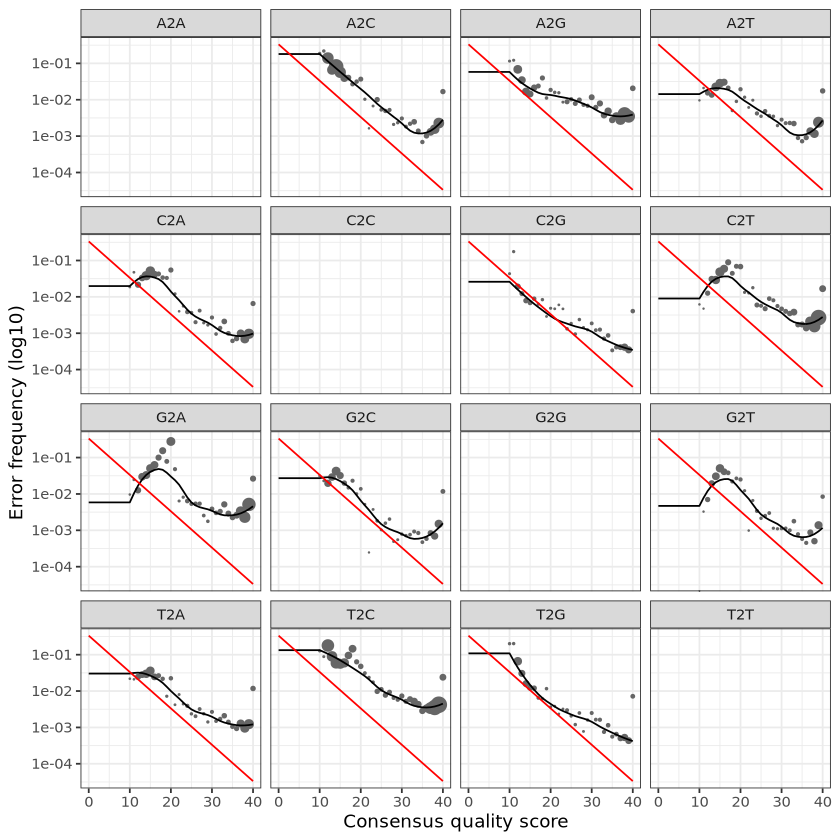

In [6]:
err_for_reads <-learnErrors(for_reads, multithread=TRUE)
plotErrors(err_for_reads, nominalQ=TRUE)

err_rev_reads <-learnErrors(rev_reads, multithread=TRUE)
plotErrors(err_rev_reads, nominalQ=TRUE)

# Deduplication

In [7]:
derep_for <- derepFastq(for_reads, verbose=TRUE)
derep_rev <- derepFastq(rev_reads, verbose=TRUE)

Dereplicating sequence entries in Fastq file: data/raw/fastq/filtered/SRR32393053_1.fastq

Encountered 694 unique sequences from 1452 total sequences read.

Dereplicating sequence entries in Fastq file: data/raw/fastq/filtered/SRR32393054_1.fastq

Encountered 7581 unique sequences from 18398 total sequences read.

Dereplicating sequence entries in Fastq file: data/raw/fastq/filtered/SRR32393055_1.fastq

Encountered 10203 unique sequences from 26438 total sequences read.

Dereplicating sequence entries in Fastq file: data/raw/fastq/filtered/SRR32393056_1.fastq

Encountered 7436 unique sequences from 19498 total sequences read.

Dereplicating sequence entries in Fastq file: data/raw/fastq/filtered/SRR32393057_1.fastq

Encountered 13144 unique sequences from 33230 total sequences read.

Dereplicating sequence entries in Fastq file: data/raw/fastq/filtered/SRR32393053_2.fastq

Encountered 1279 unique sequences from 1452 total sequences read.

Dereplicating sequence entries in Fastq file: d

# AVSs calling

In [8]:
dada_for <- dada(derep_for, err=err_for_reads, pool=T, multithread=TRUE)
dada_rev <- dada(derep_rev, err=err_rev_reads, pool=T, multithread=TRUE)

5 samples were pooled: 99016 reads in 35900 unique sequences.
5 samples were pooled: 99016 reads in 45383 unique sequences.


# Merging pair-ended reads

In [9]:
merged_amplicons <- mergePairs(
    dada_for, derep_for, 
    dada_rev, derep_rev, 
    trimOverhang=TRUE, 
    minOverlap=12
)

In [10]:
names(merged_amplicons) <- sapply(strsplit(names(merged_amplicons), "_"), `[`, 1)
names(merged_amplicons)
class(merged_amplicons$SRR32393053)
length(merged_amplicons$SRR32393053$abundance)

[1] "SRR32393053" "SRR32393054" "SRR32393055" "SRR32393056" "SRR32393057"

[1] "data.frame"

[1] 149

# Counts table

In [11]:
seqtab <- makeSequenceTable(merged_amplicons)
class(seqtab)
dim(seqtab)

[1] "matrix" "array"

[1]   5 675

# Chimera removal 

In [12]:
seqtab.nochim <- removeBimeraDenovo(seqtab, verbose=T)
sum(seqtab.nochim)/sum(seqtab) 

Identified 159 bimeras out of 675 input sequences.



[1] 0.9786271

## Taxonomy with DECIPHER

Use pertained SILVA r138.2 v2 set providing on [DECIPHER Downloads page](https://decipher.codes/Downloads.html)

In [13]:
load('data/raw/SILVA_SSU_r138.2_v2.RData')

In [14]:
fas <- DNAStringSet(getSequences(seqtab.nochim))

In [16]:
ids <- IdTaxa(fas, trainingSet, strand="top", processors=NULL, verbose=FALSE)

In [17]:
ranks <- c("domain", "phylum", "class", "order", "family", "genus", "species")
# Convert the output object of class "Taxa" to a matrix analogous to the output from assignTaxonomy
taxid <- t(sapply(ids, function(x) {
        m <- match(ranks, x$rank)
        taxa <- x$taxon[m]
        taxa[startsWith(taxa, "unclassified_")] <- NA
        taxa
}))
colnames(taxid) <- ranks
rownames(taxid) <- getSequences(seqtab.nochim)

In [29]:
dim(taxid)

[1] 516   7

# Save results

In [33]:
# giving our seq headers more manageable names (ASV_1, ASV_2...)
asv_seqs <- colnames(seqtab.nochim)
asv_headers <- vector(dim(seqtab.nochim)[2], mode="character")

for (i in 1:dim(seqtab.nochim)[2]) {
    asv_headers[i] <- paste(">ASV", i, sep="_")
}

    # making and writing out a fasta of our final ASV seqs:
asv_fasta <- c(rbind(asv_headers, asv_seqs))
write(asv_fasta, snakemake@output$fasta)

    # count table:
asv_tab <- t(seqtab.nochim)
row.names(asv_tab) <-sub(">", "", asv_headers)
write.table(asv_tab, snakemake@output$counts, sep="\t", quote=F, col.names=NA)

    # tax table:
colnames(taxid) <- ranks
rownames(taxid) <- gsub(pattern=">", replacement="", x=asv_headers)

write.table(taxid, snakemake@output$tax, sep = "\t", quote=F, col.names=NA)